# 01 — Análise Exploratória (EDA) do Churn

Objetivo: entender o dataset sintético de clientes, validar que o **sinal de negócio** existe (contrato, tenure, cobrança, suporte) e levantar hipóteses para a modelagem.

> Os dados são gerados por `src/data/generate_synthetic.py` a partir de um modelo logístico latente — ou seja, o churn tem causas interpretáveis, não é ruído.

In [1]:
import sys; sys.path.append('..')
import pandas as pd
import matplotlib.pyplot as plt
from src.data.generate_synthetic import generate_customers

df = generate_customers(n=8000, seed=42)
df.head()

,customer_id,tenure_months,contract,internet_service,payment_method,senior_citizen,partner,dependents,paperless_billing,tech_support,online_security,monthly_charges,total_charges,churn
0,C100000,6,One year,Fiber optic,Bank transfer,0,1,0,1,1,0,69.80,419.90,0
1,C100001,55,Month-to-month,Fiber optic,Credit card,1,0,1,0,1,0,75.63,3907.46,0
2,C100002,47,Two year,DSL,Electronic check,0,0,1,1,1,1,58.58,2798.41,0
3,C100003,31,Month-to-month,No,Electronic check,0,0,0,1,1,1,30.29,854.13,0
4,C100004,31,Month-to-month,DSL,Bank transfer,1,0,1,0,0,0,57.02,1662.30,0


## Visão geral e taxa de churn

In [2]:
print(df.shape)
print(df.dtypes)
print(f"Taxa de churn global: {df['churn'].mean():.1%}")
df.describe()

(8000, 14)
customer_id           object
tenure_months          int64
contract              object
internet_service      object
payment_method        object
senior_citizen         int64
partner                int64
dependents             int64
paperless_billing      int64
tech_support           int64
online_security        int64
monthly_charges      float64
total_charges        float64
churn                  int64
dtype: object
Taxa de churn global: 14.6%


,tenure_months,senior_citizen,partner,dependents,paperless_billing,tech_support,online_security,monthly_charges,total_charges,churn
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,35.155500,0.158375,0.489625,0.295625,0.588125,0.380750,0.349125,61.171234,2090.923436,0.145875
std,20.752202,0.365115,0.499924,0.456352,0.492203,0.485602,0.476723,21.972101,1519.729508,0.353003
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,16.380000,0.000000
25%,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,49.287500,819.680000,0.000000
50%,35.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,65.595000,1750.875000,0.000000
75%,53.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,77.880000,3183.812500,0.000000
max,71.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,110.260000,7089.740000,1.000000


## Churn por tipo de contrato

Hipótese de negócio: contratos mês a mês têm barreira de saída baixa e devem churnar muito mais.

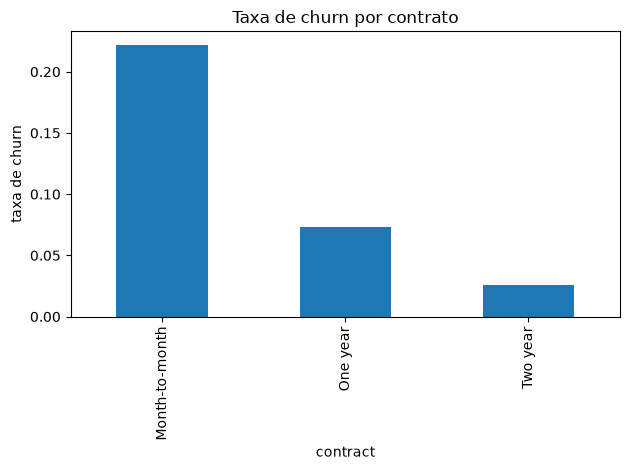

contract
Month-to-month    0.221894
One year          0.072993
Two year          0.025940
Name: churn, dtype: float64

In [3]:
by_contract = df.groupby('contract')['churn'].mean().sort_values(ascending=False)
by_contract.plot(kind='bar', title='Taxa de churn por contrato', ylabel='taxa de churn')
plt.tight_layout(); plt.show()
by_contract

## Churn por tempo de casa (tenure)

Clientes novos ainda não criaram vínculo — esperamos churn decrescente com o tenure.

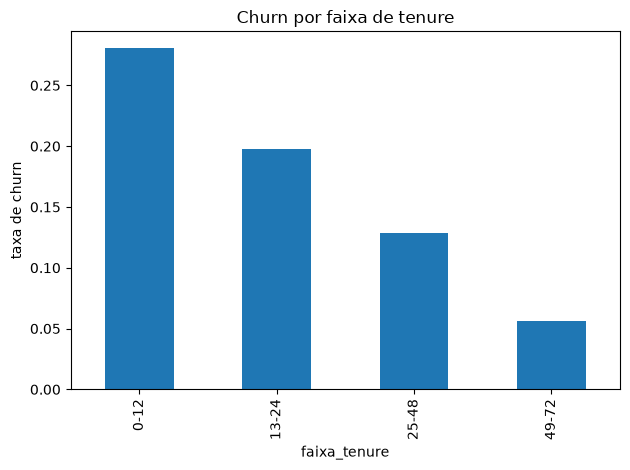

faixa_tenure
0-12     0.280405
13-24    0.197691
25-48    0.128186
49-72    0.056287
Name: churn, dtype: float64

In [4]:
df['faixa_tenure'] = pd.cut(df['tenure_months'], bins=[0,12,24,48,72],
                            labels=['0-12','13-24','25-48','49-72'], include_lowest=True)
by_tenure = df.groupby('faixa_tenure', observed=True)['churn'].mean()
by_tenure.plot(kind='bar', title='Churn por faixa de tenure', ylabel='taxa de churn')
plt.tight_layout(); plt.show()
by_tenure

## Cobrança mensal e serviço de internet

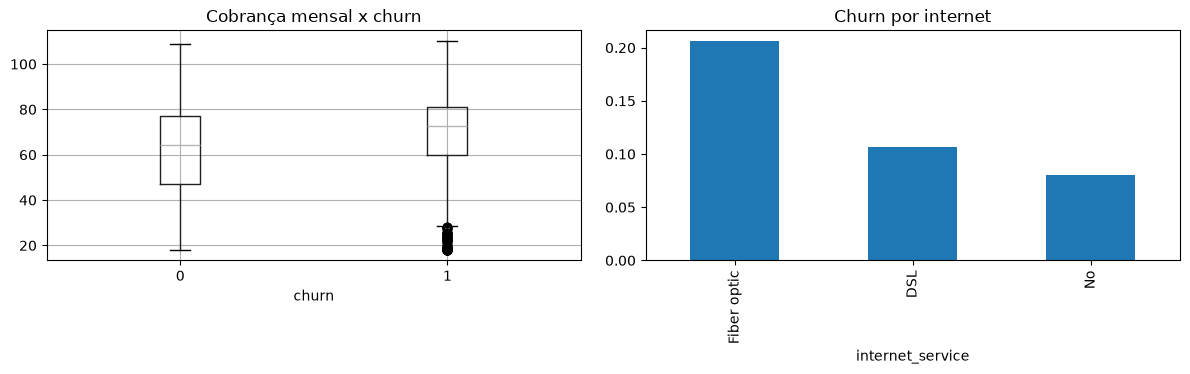

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df.boxplot(column='monthly_charges', by='churn', ax=ax[0])
ax[0].set_title('Cobrança mensal x churn')
df.groupby('internet_service')['churn'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=ax[1], title='Churn por internet')
plt.suptitle(''); plt.tight_layout(); plt.show()

## Correlação das variáveis numéricas com o churn

In [6]:
num = ['tenure_months','monthly_charges','total_charges','senior_citizen',
       'partner','dependents','tech_support','online_security','churn']
df[num].corr()['churn'].sort_values()

tenure_months     -0.230940
total_charges     -0.138192
tech_support      -0.085573
online_security   -0.064206
dependents        -0.020173
partner           -0.017988
senior_citizen     0.026360
monthly_charges    0.124625
churn              1.000000
Name: churn, dtype: float64

## Insights de negócio

1. **Contrato mês a mês é o maior fator de churn** — clientes sem fidelização saem muito mais. Ação: incentivar migração para contratos anuais.
2. **Churn cai fortemente com o tenure** — o risco se concentra nos primeiros 12 meses. Ação: onboarding e acompanhamento reforçados no início.
3. **Cobrança mensal alta e fibra ótica** elevam o churn — percepção de custo-benefício. Ação: revisar pricing/valor entregue na fibra.
4. **Suporte técnico e segurança online retêm** — quem tem esses serviços churna menos. Ação: oferecer esses add-ons como retenção.
5. **Pagamento por cheque eletrônico** correlaciona com churn (proxy de perfil menos engajado).

Esses achados guiam a feature engineering (`charges_per_tenure`, buckets de tenure) e explicam a importância que o SHAP atribui às variáveis na Etapa 5.